## How to prepare datasets of images
    prepping your image dataset right is crucial for any computer vision project, whether it's object detection, facial recognition, classification, or segmentation.

#### Step 1 : Define your task

First, ask:
What do I want my model to do?

Examples:
    
    🧑‍🦰 Face recognition → classify people
    🐶🐱 Image classification → label dog vs cat
    📦 Object detection → locate objects with bounding boxes
    ✂️ Segmentation → outline objects pixel by pixel

Different tasks need different dataset structures.

#### Step 2: Organize Your Folders
🏷️ For image classification:

    Use this folder structure: as train/


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

#Define the base folder
base_dir = "facial_recognition"

In [2]:
#Define subfolders   
train_dir = os.path.join(base_dir, "train")
classes = ["precious", "prince", "smile"]

In [3]:
#Create the base "facial_recognition" and "train" folder
os.makedirs(train_dir, exist_ok=True)

In [4]:
#Create the class subfolders inside "train"
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    os.makedirs(class_path, exist_ok=True)

print("Folder structure created successfully!")
#Now we have created a folder"facial_recognition"
#with a sub-folder "train" and three folders inside train

Folder structure created successfully!


#### Step 3: Clean the Images

Make sure your images:

    Are not blurry or corrupted
    Are properly labeled
    Don't contain unwanted objects
    Are of similar size/aspect ratio

In [5]:
path = "facial_recognition/train"

In [6]:
os.listdir(path)

['.ipynb_checkpoints', 'precious', 'prince', 'smile']


📁 Images in '.ipynb_checkpoints' folder:

📁 Images in 'precious' folder:


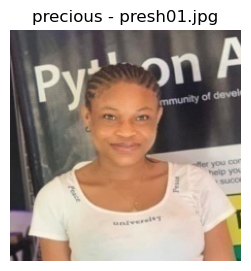

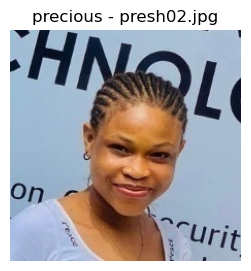

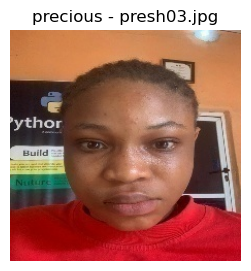

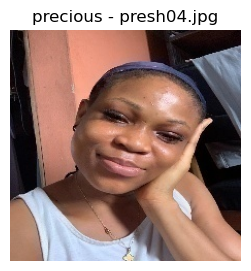


📁 Images in 'prince' folder:


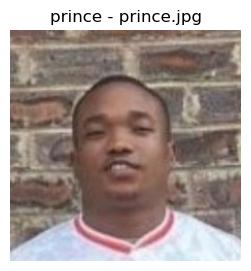

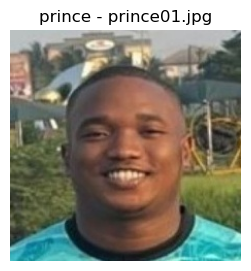

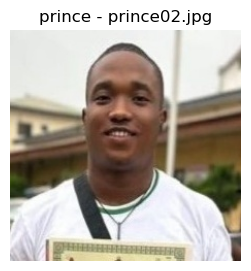

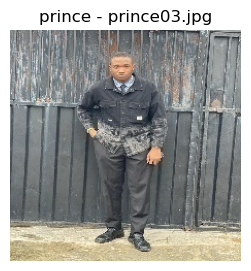


📁 Images in 'smile' folder:


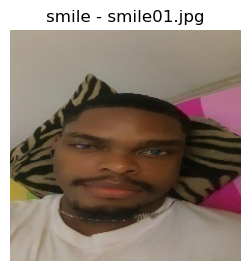

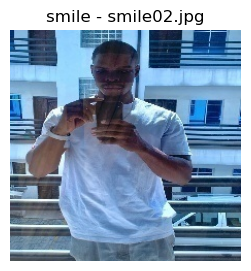

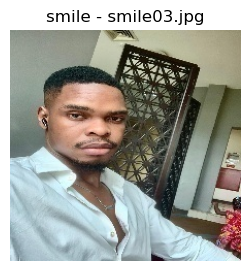

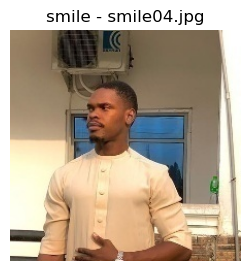

In [7]:
import cv2
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)
    #Confirm folders in directory
    if os.path.isdir(class_path):
        print(f"\n📁 Images in '{class_name}' folder:")

        # List and print image files
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            
            #Read and convert the image (BGR to RGB)
            img = cv2.imread(image_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Display the image using matplotlib
            plt.figure(figsize = (5, 3))
            plt.imshow(img_rgb)
            plt.title(f"{class_name} - {image_name}")
            plt.axis('off')
            plt.show()

#### Step 4: Resize and Normalize
    Most ML models require all images to be the same size.
    E.g., for 224x224

In [8]:
import threading

In [9]:
#Resize image
target_size = (224, 224)

#Function to resize and normalize a .jpg image
def resize_image(image_path):
    try:
        img = cv2.imread(image_path)
        if img is not None:
            #Resize
            resized = cv2.resize(img, target_size)
            
            #Normalize to [0, 1]
            normalized = resized / 255.0

            #Save resized image (not normalized, because OpenCV needs uint8)
            cv2.imwrite(image_path, resized)
            print(f"✅ Resized & normalized in memory: {image_path}")
        else:
            print(f"⚠️ Could not load: {image_path}")
    except Exception as e:
        print(f"❌ Error resizing {image_path}: {e}")

In [10]:
#Collect all images from distince paths
image_paths = []
for root, _, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_paths.append(os.path.join(root, file))

In [11]:
#Resize all images using threading
threads = []
for path in image_paths:
    t = threading.Thread(target=resize_image, args=(path,))
    threads.append(t)
    t.start()

# Wait for all threads to finish
for t in threads:
    t.join()

print("\n🎉 Done resizing all .jpg images!")

✅ Resized & normalized in memory: facial_recognition\train\precious\presh01.jpg✅ Resized & normalized in memory: facial_recognition\train\precious\presh02.jpg
✅ Resized & normalized in memory: facial_recognition\train\precious\presh03.jpg
✅ Resized & normalized in memory: facial_recognition\train\precious\presh04.jpg

✅ Resized & normalized in memory: facial_recognition\train\prince\prince.jpg
✅ Resized & normalized in memory: facial_recognition\train\prince\prince01.jpg
✅ Resized & normalized in memory: facial_recognition\train\prince\prince02.jpg
✅ Resized & normalized in memory: facial_recognition\train\prince\prince03.jpg
✅ Resized & normalized in memory: facial_recognition\train\smile\smile01.jpg
✅ Resized & normalized in memory: facial_recognition\train\smile\smile02.jpg
✅ Resized & normalized in memory: facial_recognition\train\smile\smile03.jpg
✅ Resized & normalized in memory: facial_recognition\train\smile\smile04.jpg

🎉 Done resizing all .jpg images!


##### Normalize 
    For deep learning, scale pixel values to [0, 1] or [-1, 1]:

In [12]:
threads

[<Thread(Thread-6 (resize_image), stopped 8592)>,
 <Thread(Thread-7 (resize_image), stopped 20916)>,
 <Thread(Thread-8 (resize_image), stopped 18076)>,
 <Thread(Thread-9 (resize_image), stopped 14936)>,
 <Thread(Thread-10 (resize_image), stopped 14212)>,
 <Thread(Thread-11 (resize_image), stopped 20600)>,
 <Thread(Thread-12 (resize_image), stopped 7824)>,
 <Thread(Thread-13 (resize_image), stopped 15804)>,
 <Thread(Thread-14 (resize_image), stopped 11644)>,
 <Thread(Thread-15 (resize_image), stopped 15616)>,
 <Thread(Thread-16 (resize_image), stopped 6068)>,
 <Thread(Thread-17 (resize_image), stopped 7660)>]

#### Step 5: Data Augmentation (Optional but Powerful)

    To make your model more robust, you can augment images:

    Flip, rotate, zoom, shift
    Adjust brightness, contrast
    Add blur or noise

In [13]:
# flipped = cv2.flip(img, 1)  # horizontal flip
#Or use Keras ImageDataGenerator or Albumentations.

#### Step 6: Create Labels (for Facial Recognition)

    write a face detection and cropping script that will:

Take raw images (full body or background included), detect faces, crop them, and save them into the correct person’s folder — preparing your dataset for facial recognition.

We will use
    
    OpenCV for face detection (Haar Cascade)
    os for directory handling
    cv2.CascadeClassifier to detect faces
    Images will be cropped, resized to 224x224, and saved in place

##### 6(a)  Load Haar Cascade for Frontal Face Detection

In [14]:
#Haar cascade for frontal face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
'''
This loads OpenCV's pre-trained model for detecting frontal human faces.
'''

"\nThis loads OpenCV's pre-trained model for detecting frontal human faces.\n"

##### 6(b) Set Input and Output Paths

In [15]:
# Set paths
input_root = "facial_recognition"   #already resized/normalized folders
output_root = "cropped_faces"      #to store face-only crops
target_size = (224, 224)

Create CSV Output path

In [16]:
# CSV output
csv_path = "face_coordinates.csv"
csv_data = [("image_path", "x", "y", "w", "h")]

##### 6(c) Crop and save each face in repo, then Save Face coordinates in CSV files

Loop Over Each Person’s Folder

Detect face using pretrained model

Crop and save each face in defined repository

In [17]:
import csv

In [18]:
#Go through each subset folder
for subset in os.listdir(input_root):
    subset_path = os.path.join(input_root, subset)
    if not os.path.isdir(subset_path):
        continue
   #Go through each person's folder
    for person in os.listdir(subset_path):
        person_dir = os.path.join(subset_path, person)
        if not os.path.isdir(person_dir):
            continue

        save_dir = os.path.join(output_root, subset, person)
        os.makedirs(save_dir, exist_ok=True)

        image_files = [f for f in os.listdir(person_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        print(f"🔍 Searching in: {person_dir}")
        print(f"📸 Found {len(image_files)} images for '{person}'")

        for img_name in image_files:
            img_path = os.path.join(person_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                print(f"❌ Failed to read: {img_path}")
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

            if len(faces) == 0:
                print(f"⚠️ No face found in {img_path}")
                continue

            #Use largest face
            x, y, w, h = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)[0]
            face_crop = img[y:y + h, x:x + w]
            

            #Resize to match target size
            face_crop = cv2.resize(face_crop, target_size)

            #Save the cropped face
            save_path = os.path.join(save_dir, img_name)
            cv2.imwrite(save_path, face_crop)
            print(f"✅ Cropped and saved: {save_path}")
            #Log original path and face coordinates
            csv_data.append((img_path, x, y, w, h))

#Save all to CSV
with open(csv_path, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(csv_data)

🔍 Searching in: facial_recognition\train\.ipynb_checkpoints
📸 Found 0 images for '.ipynb_checkpoints'
🔍 Searching in: facial_recognition\train\precious
📸 Found 4 images for 'precious'
✅ Cropped and saved: cropped_faces\train\precious\presh01.jpg
✅ Cropped and saved: cropped_faces\train\precious\presh02.jpg
✅ Cropped and saved: cropped_faces\train\precious\presh03.jpg
✅ Cropped and saved: cropped_faces\train\precious\presh04.jpg
🔍 Searching in: facial_recognition\train\prince
📸 Found 4 images for 'prince'
✅ Cropped and saved: cropped_faces\train\prince\prince.jpg
✅ Cropped and saved: cropped_faces\train\prince\prince01.jpg
✅ Cropped and saved: cropped_faces\train\prince\prince02.jpg
⚠️ No face found in facial_recognition\train\prince\prince03.jpg
🔍 Searching in: facial_recognition\train\smile
📸 Found 4 images for 'smile'
✅ Cropped and saved: cropped_faces\train\smile\smile01.jpg
⚠️ No face found in facial_recognition\train\smile\smile02.jpg
✅ Cropped and saved: cropped_faces\train\smile

#### 7 Build Face recognition model

    We’ll use TensorFlow + Keras (simpler on CPU):
    
    📁 Load data from folders
    
    🏗️ Build a CNN model
    
    🏃‍♀️ Train the model
    
    💾 Save the trained model

In [19]:
#import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


##### 7(a) Define Paths and Parameters

In [20]:
#Path to cropped face data
data_dir = "cropped_faces/train"

#Basic parameters
img_height = 224
img_width = 224
batch_size = 32
num_epochs = 10


##### 7(b) Load Data from Directory

In [21]:
# Load and label data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=123
    )
    
class_names = train_ds.class_names
print("✅ Classes:", class_names)


Found 11 files belonging to 3 classes.
✅ Classes: ['precious', 'prince', 'smile']


##### 7(c) Build the CNN Model

In [22]:
#intialize the model
model = models.Sequential()

In [23]:
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)))  # Make sure to define input shape here

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.add(layers.MaxPooling2D())

In [25]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))


In [26]:
model.add(layers.MaxPooling2D())

In [27]:
model.add(layers.Conv2D(128, (3,3), activation='relu'))


In [28]:
model.add(layers.MaxPooling2D())


In [29]:
model.add(layers.Flatten())

In [30]:
model.add(layers.Dense(128, activation='relu'))

In [31]:
model.add(layers.Dropout(0.5))

In [32]:
model.add(layers.Dense(len(class_names), activation='softmax'))

Compile the Model

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [35]:
history = model.fit(
    train_ds,
    epochs=num_epochs
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1818 - loss: 16.0188
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4545 - loss: 334.2074
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5455 - loss: 230.6669
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3636 - loss: 85.8385
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5455 - loss: 19.5567
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7273 - loss: 7.4909
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8182 - loss: 6.6731
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5455 - loss: 7.7405
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0038
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6364 - loss: 7.2264


#### Evaluate model performance

In [67]:
#Load test image
test_dir = r"C:\Users\USER\3D Objects\presh05.jpg"
# === Load and Preprocess Image ===
test_img = cv2.imread(test_dir)


if test_img is None:
    print("❌ Failed to load image.")
else:
   print("Image found")

#convert to RBG
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

Image found


In [68]:
#Step 2: Convert from float32 [0,1] → uint8 [0,255]
# img_uint8 = (test_img * 255).astype('uint8')

#integrate the modell with pre-trained face detector, so the model can focus on the face 
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)  #first convert image to grey

#Detect face
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3)
#the above object scans the image and returns a list of rectangles 
#where it detects faces

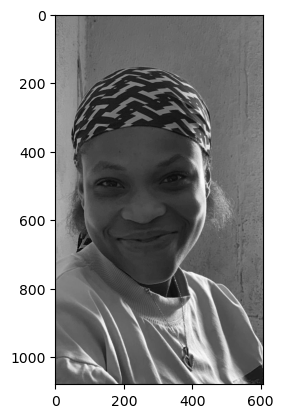

In [69]:
plt.imshow(gray, cmap='gray')

In [70]:
if len(faces) == 0:
    print("⚠️ No face detected in the image.")

In [71]:
#Step 5: Crop the largest detected face
x, y, w, h = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)[0]
face = test_img[y:y+h, x:x+w]

#Step 6: Resize cropped face to 224x224
face_resized = cv2.resize(face, (224, 224))

#Step 7: Normalize and re-add batch dimension
face_normalized = face_resized.astype('float32') / 255.0
input_tensor = np.expand_dims(face_normalized, axis=0)  # shape = (1, 224, 224, 3)

#✅ Now input_tensor is ready for your model!

In [73]:
# === Predict ===
predictions = model.predict(input_tensor)
predicted_index = np.argmax(predictions[0])
predicted_label = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print(f"✅ Predicted: {predicted_label} ({confidence:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
✅ Predicted: precious (33.73%)
